工具调用
***
- 工具定义
- 工具绑定
- 工具调用
- 工具执行

工具定义
***

In [6]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool

from langgraph.prebuilt import ToolNode

In [7]:
@tool
def get_weather(location: str):
    """调用此函数获取当前天气"""
    if location.lower() in ['北京', '上海', '广州', '深圳']:
        return "现在是20度，有雾。"
    else:
        return "现在是10度，晴朗。"

@tool
def get_coolest_cites():
    """获取最冷城市列表"""    
    return "北京, 哈尔滨"

In [4]:
tools = [get_weather, get_coolest_cites]
tool_node = ToolNode(tools)

langgraph提供了低层面的封装，可以直接手动执行工具

In [ ]:
message_with_single_tool_call = AIMessage(
    content="",
    tool_calls=[
        {
           "name": "get_weather",
           "args": {"location": "北京"},
           "id": "tool_call_id",
           "type": "tool_call"
        }
    ],
)
tool_node.invoke({"messages": [message_with_single_tool_call]})

绑定工具
***

In [ ]:
from langchain_deepseek import ChatDeepseek
model_with_tool = ChatDeepseek(temperature=0).bind_tools(tools)

在ReAct智能体中执
***

In [14]:
from typing import Literal
from langgraph.graph import StateGraph, MessagesState, START, END 

def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    return END

def call_model(state: MessagesState):
    messages = state["messages"]
    response = model_with_tool.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, ['tools', END])
workflow.add_edge("tools", "agent")

app = workflow.compile()

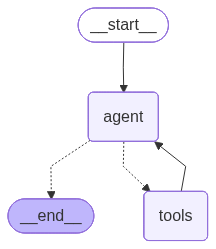

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in app.stream(
   {"messages": [("human", "深圳的天气如何")]}, stream_mode="values"
):
    chunk["messages"][-1].pretty_print()